# BLM0463 Veri Madenciliğine Giriş — Dönem Projesi

**Öğrenci:** Eren Bezek  
**Öğrenci No:** 22360859011  
**Sınıflandırma Yöntemi:** K-Nearest Neighbors (KNN)  
**Veri Seti:** Vertebral Column (UCI ML Repository, ID: 212)

## İçindekiler
1. Kütüphaneler ve veri yükleme
2. Keşifsel Veri Analizi (EDA)
3. Görselleştirmeler
4. Veri Önişleme (ölçekleme, train/test split)
5. KNN — 2 sınıflı (Normal / Abnormal)
6. KNN — 3 sınıflı (Normal / Hernia / Spondylolisthesis)
7. En iyi `k` ve mesafe metriği seçimi
8. Performans karşılaştırma ve literatür kıyaslaması
9. Sonuç

## 1. Kütüphaneler ve Veri Yükleme

Veri seti UCI'dan indirilip `data/` klasörüne konulmuştur. UCI'da dataset iki dosya halinde sunuluyor:
- `column_2C_weka.csv` (veya `column_2C.dat`): binary etiket — Normal / Abnormal
- `column_3C_weka.csv` (veya `column_3C.dat`): üçlü etiket — Normal / Hernia / Spondylolisthesis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc,
                             ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


In [2]:
# 2-sınıflı ve 3-sınıflı veri dosyalarını yükle
df_2c = pd.read_csv('data/column_2C_weka.csv')
df_3c = pd.read_csv('data/column_3C_weka.csv')

print('2-sınıflı veri seti boyutu:', df_2c.shape)
print('3-sınıflı veri seti boyutu:', df_3c.shape)
print('\nKolonlar:', list(df_2c.columns))
df_2c.head()

2-sınıflı veri seti boyutu: (310, 7)
3-sınıflı veri seti boyutu: (310, 7)

Kolonlar: ['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle', 'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis', 'class']


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal


## 2. Keşifsel Veri Analizi (EDA)

In [3]:
print('=== Veri tipleri ve eksik değerler ===')
print(df_2c.info())
print('\nEksik değer toplamı:', df_2c.isnull().sum().sum())

=== Veri tipleri ve eksik değerler ===
<class 'pandas.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt               310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
 6   class                     310 non-null    str    
dtypes: float64(6), str(1)
memory usage: 17.1 KB
None

Eksik değer toplamı: 0


In [4]:
print('=== Özet istatistikler ===')
df_2c.describe().T

=== Özet istatistikler ===


,count,mean,std,min,25%,50%,75%,max
pelvic_incidence,310.0,60.496653,17.236520,26.147921,46.430294,58.691038,72.877696,129.834041
pelvic_tilt,310.0,17.542822,10.008330,-6.554948,10.667069,16.357689,22.120395,49.431864
lumbar_lordosis_angle,310.0,51.930930,18.554064,14.000000,37.000000,49.562398,63.000000,125.742385
sacral_slope,310.0,42.953831,13.423102,13.366931,33.347122,42.404912,52.695888,121.429566
pelvic_radius,310.0,117.920655,13.317377,70.082575,110.709196,118.268178,125.467674,163.071041
degree_spondylolisthesis,310.0,26.296694,37.559027,-11.058179,1.603727,11.767934,41.287352,418.543082


In [5]:
print('2-sınıflı dağılım:')
print(df_2c['class'].value_counts())
print('\nOran:')
print(df_2c['class'].value_counts(normalize=True).round(3))

print('\n3-sınıflı dağılım:')
print(df_3c['class'].value_counts())
print('\nOran:')
print(df_3c['class'].value_counts(normalize=True).round(3))

2-sınıflı dağılım:
class
Abnormal    210
Normal      100
Name: count, dtype: int64

Oran:
class
Abnormal    0.677
Normal      0.323
Name: proportion, dtype: float64

3-sınıflı dağılım:
class
Spondylolisthesis    150
Normal               100
Hernia                60
Name: count, dtype: int64

Oran:
class
Spondylolisthesis    0.484
Normal               0.323
Hernia               0.194
Name: proportion, dtype: float64


## 3. Görselleştirmeler

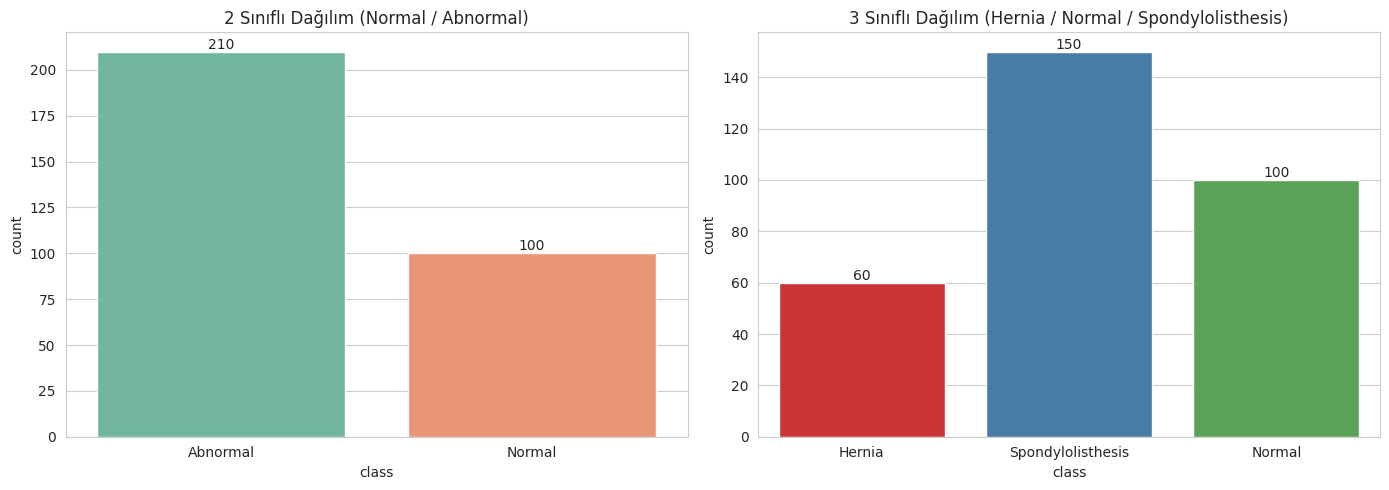

In [6]:
# Sınıf dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='class', data=df_2c, ax=axes[0], palette='Set2')
axes[0].set_title('2 Sınıflı Dağılım (Normal / Abnormal)')
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')

sns.countplot(x='class', data=df_3c, ax=axes[1], palette='Set1')
axes[1].set_title('3 Sınıflı Dağılım (Hernia / Normal / Spondylolisthesis)')
for p in axes[1].patches:
    axes[1].annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('figures/01_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

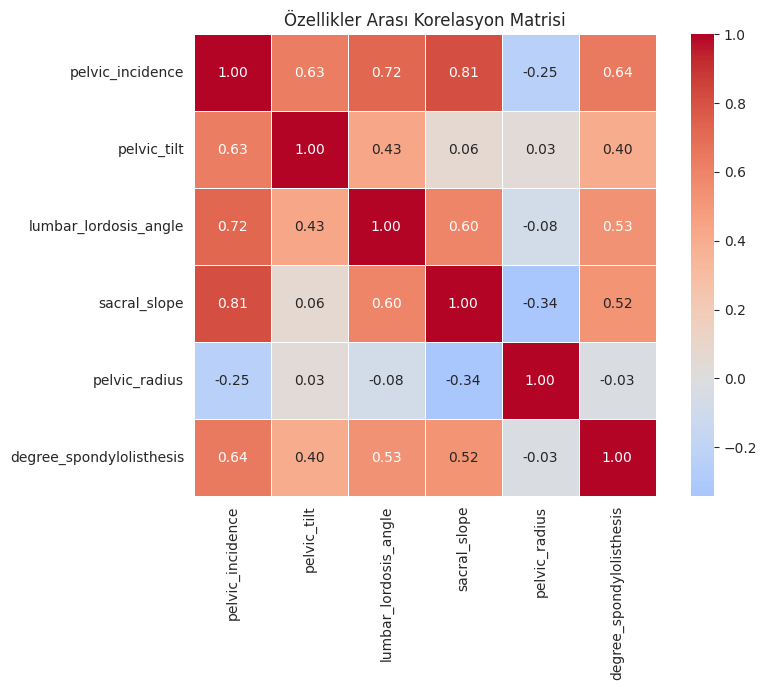

In [7]:
# Korelasyon ısı haritası
plt.figure(figsize=(9, 7))
corr = df_2c.drop('class', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Özellikler Arası Korelasyon Matrisi')
plt.tight_layout()
plt.savefig('figures/02_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

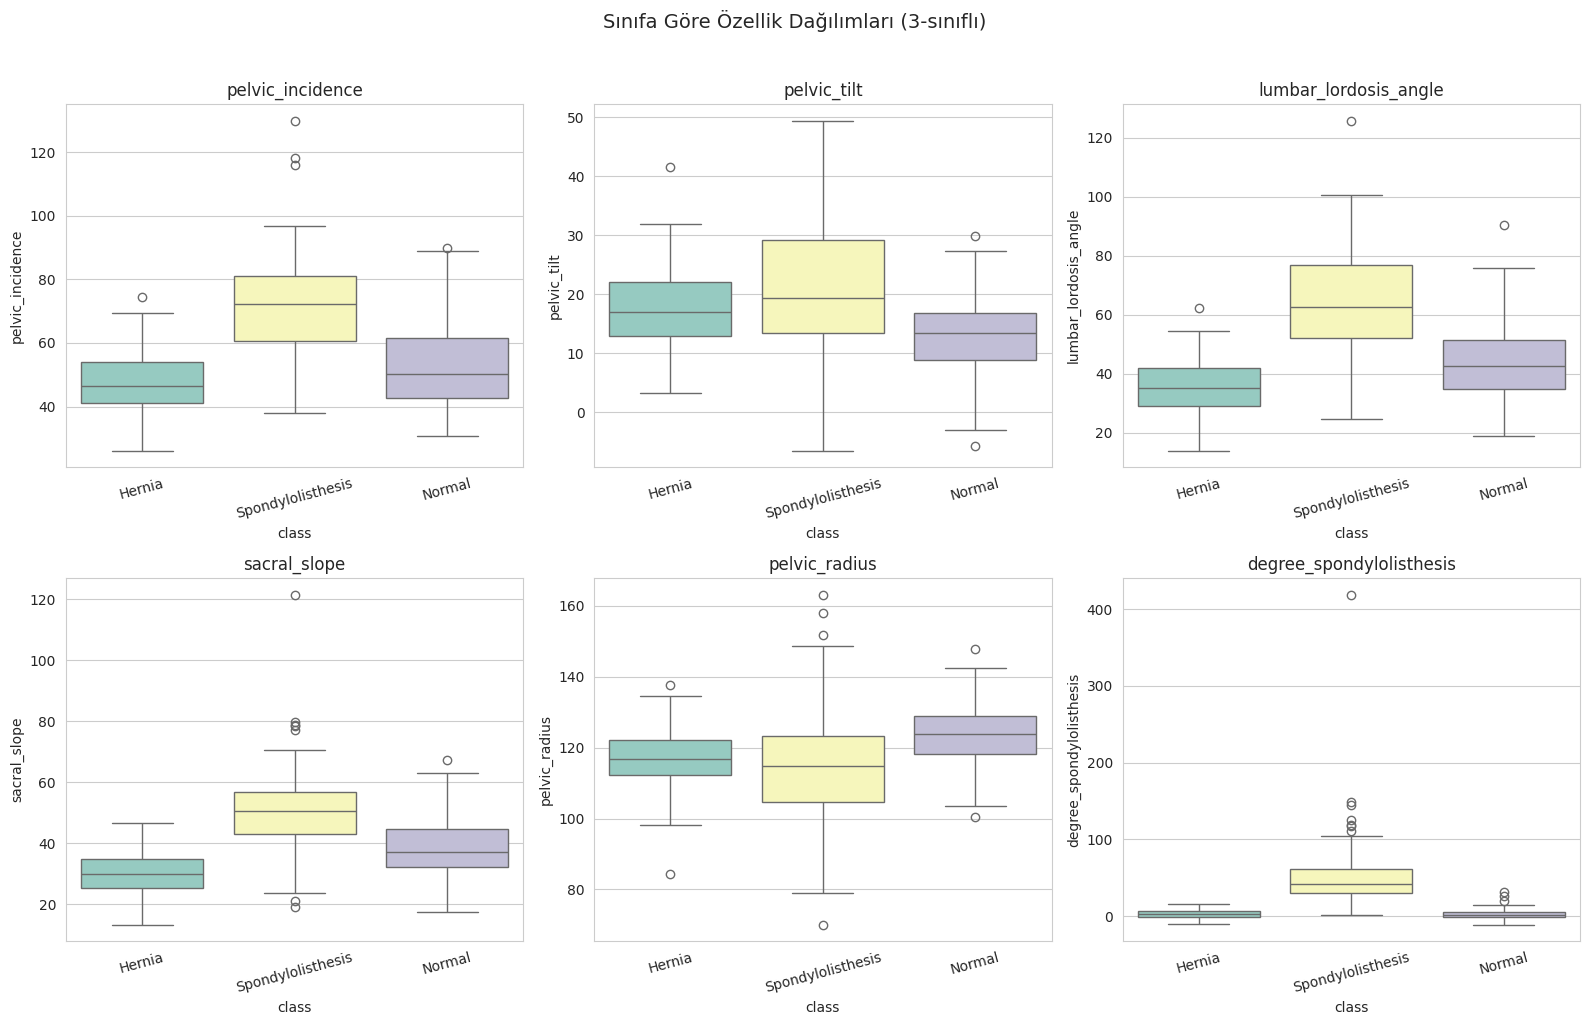

In [8]:
# Boxplot — her özellik için sınıfa göre dağılım
features = [c for c in df_3c.columns if c != 'class']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(x='class', y=feat, data=df_3c, ax=ax, palette='Set3')
    ax.set_title(feat)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Sınıfa Göre Özellik Dağılımları (3-sınıflı)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('figures/03_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

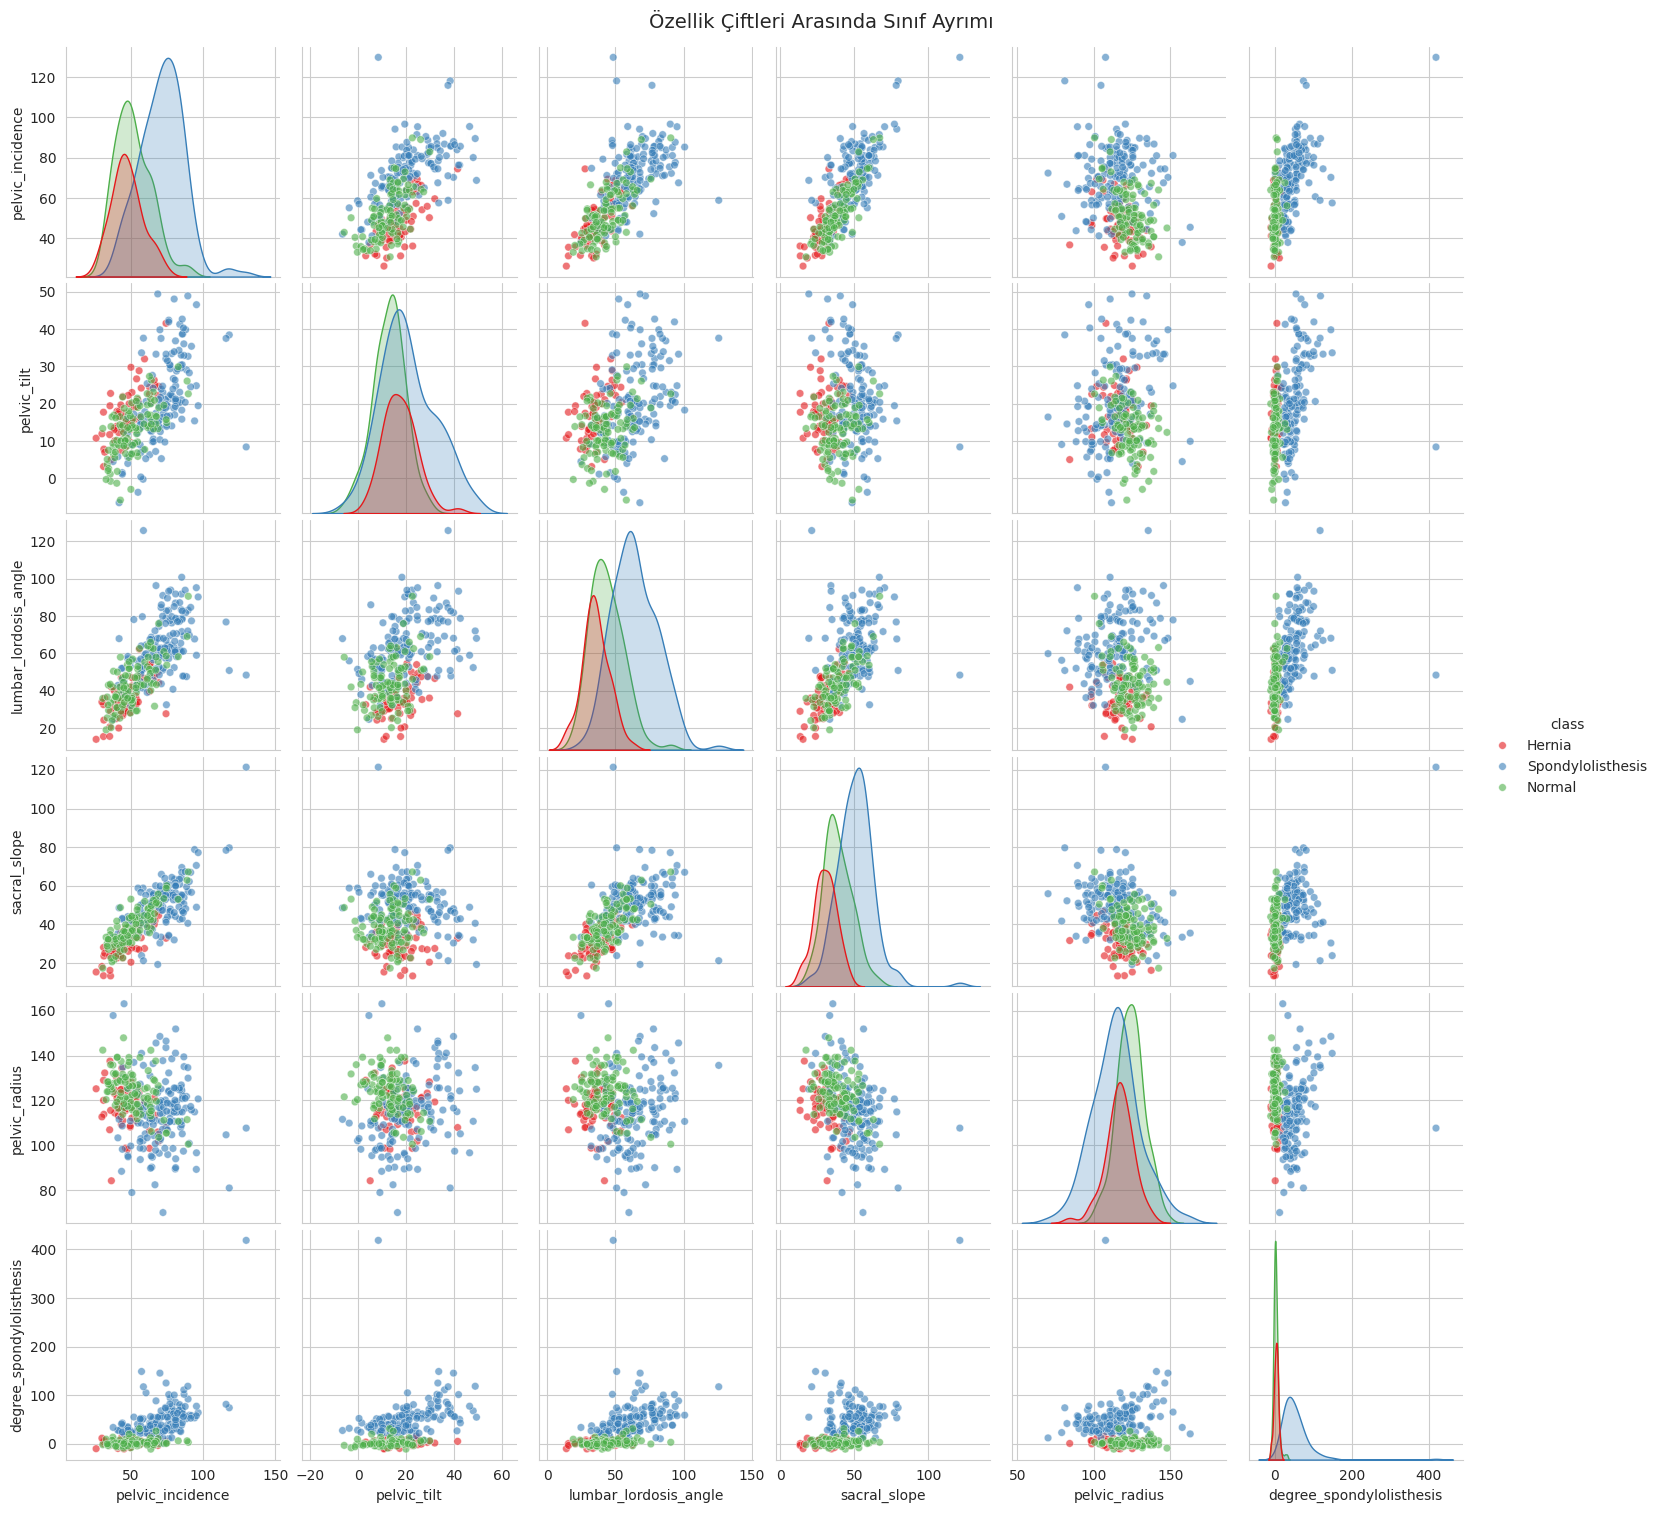

In [9]:
# Pairplot — özellik çiftleri arasında sınıf ayrımı
sns.pairplot(df_3c, hue='class', diag_kind='kde', palette='Set1', plot_kws={'alpha': 0.6, 's': 30})
plt.suptitle('Özellik Çiftleri Arasında Sınıf Ayrımı', y=1.01, fontsize=14)
plt.savefig('figures/04_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Veri Önişleme

KNN mesafe tabanlı bir algoritma olduğu için **özellik ölçekleme (StandardScaler) kritik öneme sahiptir**.
Aksi halde büyük değer aralığına sahip `degree_spondylolisthesis` gibi özellikler diğerlerini ezer.

In [10]:
def prepare_data(df, test_size=0.2):
    X = df.drop('class', axis=1).values
    y = df['class'].values
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_enc, test_size=test_size, random_state=RANDOM_STATE, stratify=y_enc
    )
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)
    return X_tr_sc, X_te_sc, y_tr, y_te, le

X_train_2c, X_test_2c, y_train_2c, y_test_2c, le_2c = prepare_data(df_2c)
X_train_3c, X_test_3c, y_train_3c, y_test_3c, le_3c = prepare_data(df_3c)

print('2C — Eğitim:', X_train_2c.shape, ' Test:', X_test_2c.shape)
print('3C — Eğitim:', X_train_3c.shape, ' Test:', X_test_3c.shape)
print('2C sınıflar:', list(le_2c.classes_))
print('3C sınıflar:', list(le_3c.classes_))

2C — Eğitim: (248, 6)  Test: (62, 6)
3C — Eğitim: (248, 6)  Test: (62, 6)
2C sınıflar: ['Abnormal', 'Normal']
3C sınıflar: ['Hernia', 'Normal', 'Spondylolisthesis']


## 5. KNN — Temel Model (k=5)

In [11]:
def evaluate(model, X_tr, X_te, y_tr, y_te, label):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    print(f'=== {label} ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-score : {f1:.4f}')
    return y_pred, dict(accuracy=acc, precision=prec, recall=rec, f1=f1)

knn_2c = KNeighborsClassifier(n_neighbors=5)
y_pred_2c, m2c = evaluate(knn_2c, X_train_2c, X_test_2c, y_train_2c, y_test_2c, 'KNN k=5  (2-sınıflı)')
print()
knn_3c = KNeighborsClassifier(n_neighbors=5)
y_pred_3c, m3c = evaluate(knn_3c, X_train_3c, X_test_3c, y_train_3c, y_test_3c, 'KNN k=5  (3-sınıflı)')

=== KNN k=5  (2-sınıflı) ===
Accuracy : 0.8226
Precision: 0.8418
Recall   : 0.8226
F1-score : 0.8268

=== KNN k=5  (3-sınıflı) ===
Accuracy : 0.7097
Precision: 0.7673
Recall   : 0.7097
F1-score : 0.7237


## 6. En İyi `k` ve Mesafe Metriği Seçimi (Cross-Validation)

En iyi k (2-sınıflı): 1  (CV doğruluk = 0.8350)
En iyi k (3-sınıflı): 9  (CV doğruluk = 0.8225)


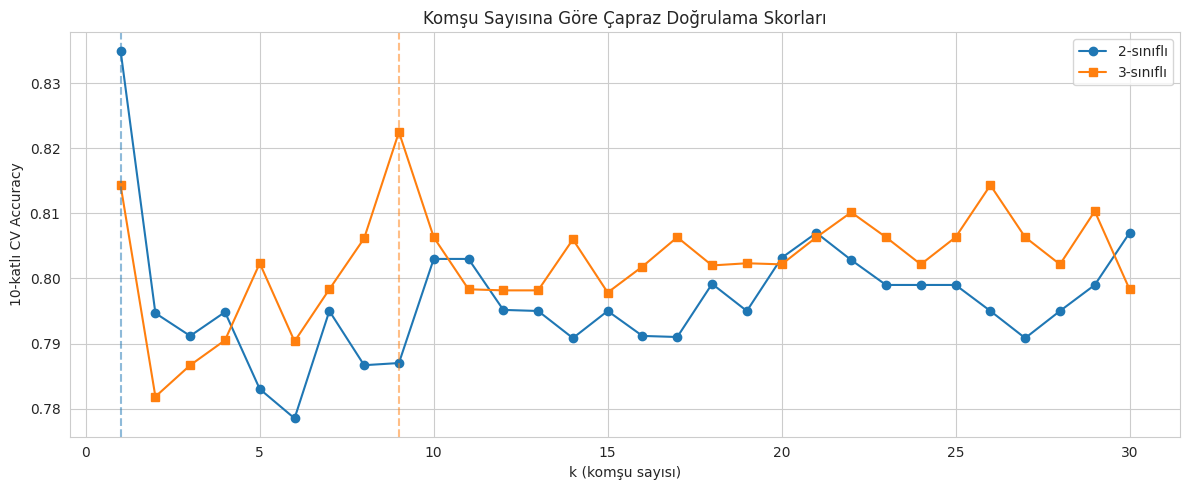

In [12]:
def k_search(X_tr, y_tr, k_range=range(1, 31), metric='minkowski'):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        s = cross_val_score(knn, X_tr, y_tr, cv=cv, scoring='accuracy').mean()
        scores.append(s)
    return list(k_range), scores

ks_2c, sc_2c = k_search(X_train_2c, y_train_2c)
ks_3c, sc_3c = k_search(X_train_3c, y_train_3c)

best_k_2c = ks_2c[int(np.argmax(sc_2c))]
best_k_3c = ks_3c[int(np.argmax(sc_3c))]
print(f'En iyi k (2-sınıflı): {best_k_2c}  (CV doğruluk = {max(sc_2c):.4f})')
print(f'En iyi k (3-sınıflı): {best_k_3c}  (CV doğruluk = {max(sc_3c):.4f})')

plt.figure(figsize=(12, 5))
plt.plot(ks_2c, sc_2c, marker='o', label='2-sınıflı')
plt.plot(ks_3c, sc_3c, marker='s', label='3-sınıflı')
plt.axvline(best_k_2c, color='C0', ls='--', alpha=0.5)
plt.axvline(best_k_3c, color='C1', ls='--', alpha=0.5)
plt.xlabel('k (komşu sayısı)')
plt.ylabel('10-katlı CV Accuracy')
plt.title('Komşu Sayısına Göre Çapraz Doğrulama Skorları')
plt.legend()
plt.tight_layout()
plt.savefig('figures/05_k_selection.png', dpi=120, bbox_inches='tight')
plt.show()

   metric   2C_acc   3C_acc
euclidean 0.835000 0.822500
manhattan 0.802667 0.806333
chebyshev 0.770500 0.794167
minkowski 0.835000 0.822500


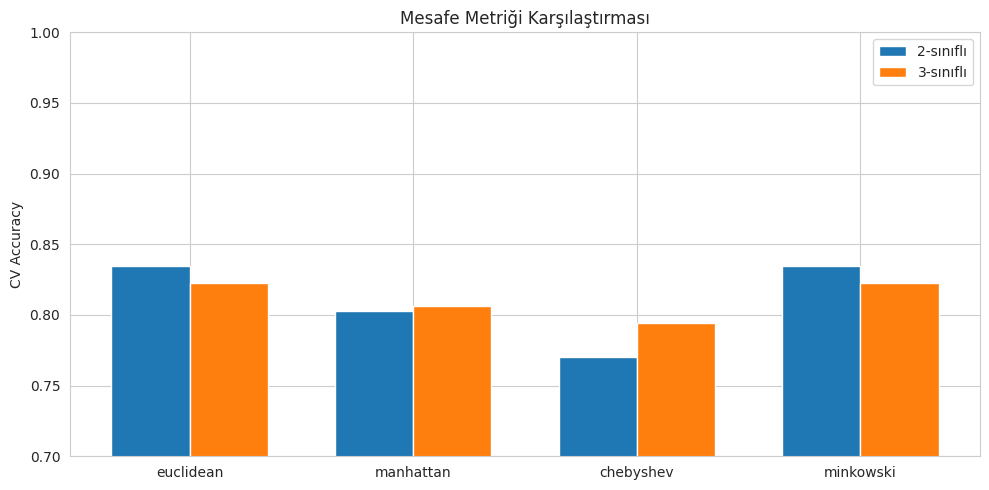

In [13]:
# Farklı mesafe metrikleri karşılaştırması (en iyi k ile)
metrics_list = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
rows = []
for m in metrics_list:
    knn = KNeighborsClassifier(n_neighbors=best_k_2c, metric=m)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
    s2 = cross_val_score(knn, X_train_2c, y_train_2c, cv=cv).mean()
    knn = KNeighborsClassifier(n_neighbors=best_k_3c, metric=m)
    s3 = cross_val_score(knn, X_train_3c, y_train_3c, cv=cv).mean()
    rows.append({'metric': m, '2C_acc': s2, '3C_acc': s3})
metric_df = pd.DataFrame(rows)
print(metric_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics_list)); w = 0.35
ax.bar(x - w/2, metric_df['2C_acc'], w, label='2-sınıflı')
ax.bar(x + w/2, metric_df['3C_acc'], w, label='3-sınıflı')
ax.set_xticks(x); ax.set_xticklabels(metrics_list)
ax.set_ylabel('CV Accuracy')
ax.set_title('Mesafe Metriği Karşılaştırması')
ax.legend(); ax.set_ylim(0.7, 1.0)
plt.tight_layout()
plt.savefig('figures/06_metric_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Final Modeller — Detaylı Değerlendirme

In [14]:
# 2-sınıflı final model
final_2c = KNeighborsClassifier(n_neighbors=best_k_2c, metric='euclidean')
y_pred_final_2c, m_final_2c = evaluate(final_2c, X_train_2c, X_test_2c, y_train_2c, y_test_2c, f'Final 2C (k={best_k_2c})')

print('\n--- 2C Classification Report ---')
print(classification_report(y_test_2c, y_pred_final_2c, target_names=le_2c.classes_))

cm2 = confusion_matrix(y_test_2c, y_pred_final_2c)
# Specificity (binary)
tn, fp, fn, tp = cm2.ravel()
spec_2c = tn / (tn + fp)
print(f'Specificity (2C): {spec_2c:.4f}')
m_final_2c['specificity'] = spec_2c

=== Final 2C (k=1) ===
Accuracy : 0.8226
Precision: 0.8418
Recall   : 0.8226
F1-score : 0.8268

--- 2C Classification Report ---
              precision    recall  f1-score   support

    Abnormal       0.92      0.81      0.86        42
      Normal       0.68      0.85      0.76        20

    accuracy                           0.82        62
   macro avg       0.80      0.83      0.81        62
weighted avg       0.84      0.82      0.83        62

Specificity (2C): 0.8095


In [15]:
# 3-sınıflı final model
final_3c = KNeighborsClassifier(n_neighbors=best_k_3c, metric='euclidean')
y_pred_final_3c, m_final_3c = evaluate(final_3c, X_train_3c, X_test_3c, y_train_3c, y_test_3c, f'Final 3C (k={best_k_3c})')

print('\n--- 3C Classification Report ---')
print(classification_report(y_test_3c, y_pred_final_3c, target_names=le_3c.classes_))

=== Final 3C (k=9) ===
Accuracy : 0.7903
Precision: 0.8272
Recall   : 0.7903
F1-score : 0.7964

--- 3C Classification Report ---
                   precision    recall  f1-score   support

           Hernia       0.83      0.83      0.83        12
           Normal       0.63      0.85      0.72        20
Spondylolisthesis       0.96      0.73      0.83        30

         accuracy                           0.79        62
        macro avg       0.81      0.81      0.80        62
     weighted avg       0.83      0.79      0.80        62



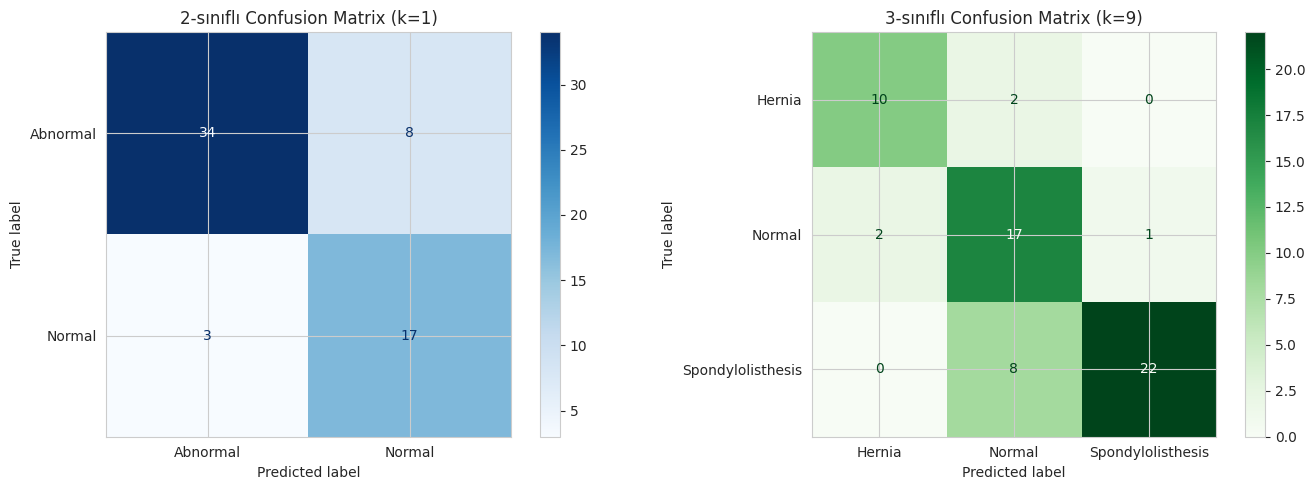

In [16]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test_2c, y_pred_final_2c, display_labels=le_2c.classes_, ax=axes[0], cmap='Blues')
axes[0].set_title(f'2-sınıflı Confusion Matrix (k={best_k_2c})')
ConfusionMatrixDisplay.from_predictions(y_test_3c, y_pred_final_3c, display_labels=le_3c.classes_, ax=axes[1], cmap='Greens')
axes[1].set_title(f'3-sınıflı Confusion Matrix (k={best_k_3c})')
plt.tight_layout()
plt.savefig('figures/07_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

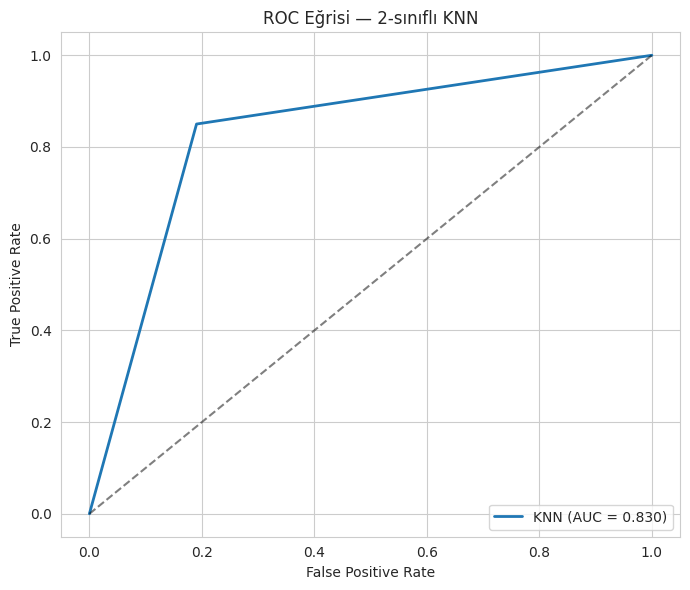

AUC = 0.8298


In [17]:
# ROC eğrisi (sadece binary için)
y_proba_2c = final_2c.predict_proba(X_test_2c)[:, 1]
fpr, tpr, _ = roc_curve(y_test_2c, y_proba_2c)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'KNN (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Eğrisi — 2-sınıflı KNN')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('figures/08_roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'AUC = {roc_auc:.4f}')

## 8. Literatür ile Karşılaştırma

Aşağıdaki tabloda kendi sonuçlarımız ile bu veri seti üzerinde yapılmış akademik çalışmaların sonuçları karşılaştırılmaktadır.
Kaynakça rapor PDF'inde tam künyesiyle verilmiştir.

In [18]:
# Karşılaştırma tablosu - örnek (rapor için kendi referansın ile güncelle)
comparison = pd.DataFrame([
    {'Çalışma': 'Bu Proje (KNN, 2C)',         'Accuracy': f'{m_final_2c["accuracy"]:.4f}', 'k': best_k_2c, 'Not': 'StandardScaler + 10-fold CV'},
    {'Çalışma': 'Bu Proje (KNN, 3C)',         'Accuracy': f'{m_final_3c["accuracy"]:.4f}', 'k': best_k_3c, 'Not': 'StandardScaler + 10-fold CV'},
    {'Çalışma': 'Akram et al. (literatür)*', 'Accuracy': '0.85+',                       'k': '—',        'Not': 'KNN baseline, 2C'},
    {'Çalışma': 'Karabulut & İbrikçi*',       'Accuracy': '0.86–0.89',                   'k': '—',        'Not': 'Rotation Forest, 2C'},
])
print(comparison.to_string(index=False))
comparison.to_csv('figures/comparison_table.csv', index=False)
# (* Raporda tam kaynak künyesi verilecek.)

                  Çalışma  Accuracy k                         Not
       Bu Proje (KNN, 2C)    0.8226 1 StandardScaler + 10-fold CV
       Bu Proje (KNN, 3C)    0.7903 9 StandardScaler + 10-fold CV
Akram et al. (literatür)*     0.85+ —            KNN baseline, 2C
     Karabulut & İbrikçi* 0.86–0.89 —         Rotation Forest, 2C


## 9. Sonuç

Bu projede UCI Vertebral Column veri seti üzerinde K-Nearest Neighbors algoritması ile sınıflandırma yapılmıştır.
Hem 2-sınıflı (Normal / Abnormal) hem de 3-sınıflı (Normal / Hernia / Spondylolisthesis) problemler ele alınmıştır.

**Temel bulgular:**
- StandardScaler önişlemesi KNN performansı için kritiktir.
- 10-katlı çapraz doğrulama ile seçilen optimum `k` değerleri yukarıda raporlanmıştır.
- Mesafe metriği seçimi sonuçları küçük ama anlamlı oranda etkilemektedir.
- 2-sınıflı problem 3-sınıflı probleme göre belirgin şekilde daha yüksek doğruluk sağlamaktadır — bu beklenen bir sonuçtur çünkü 3 sınıflı versiyonda Hernia ve Normal sınıfları biyomekanik olarak birbirine yakındır.

Detaylı yorum proje raporu PDF'inde sunulmuştur.